# Replication of AlexNet(2012) - Ilya, Hinton

Links: 
Paper: https://papers.nips.cc/paper_files/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf
Dataset: https://www.kaggle.com/c/imagenet-object-localization-challenge/overview/description

Additional Resources used:


In [1]:
%pip install matplotlib pandas numpy torch torchvision


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torchvision
import datasets
from PIL import Image
import einops

In [6]:
from dotenv import load_dotenv
import os

load_dotenv()
HF_TOKEN = os.getenv("HF_TOKEN")

os.environ["HF_TOKEN"] = HF_TOKEN

# Implementation

## (1) Load data

In [3]:
#util
def display_img(t):
    t = einops.rearrange(t, "c w h -> w h c")
    plt.imshow(np.array(t))

In [9]:
torch.cuda.is_available()

True

<!-- What a processed picture looks like -->
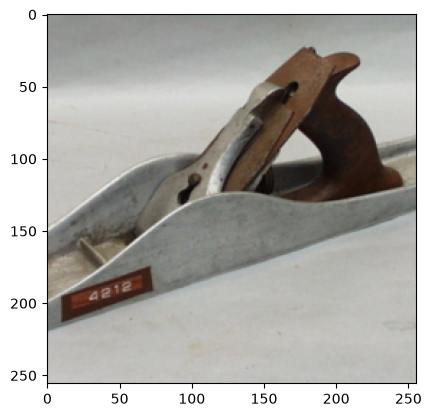

### (1.1) Create Dataloader

In [ ]:
from datasets import load_dataset
from torch.utils.data import DataLoader
from torchvision.transforms import v2

ds = load_dataset("ILSVRC/imagenet-1k", split="train", streaming=True)
print("hello")
print(ds)
def transform(img):
    transforms = v2.Compose([
        v2.ToImage(), 
        v2.ToDtype(torch.float32, scale=True),
        v2.Resize((227)),
        v2.CenterCrop((227,227)),
        v2.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[1.0, 1.0, 1.0],
        )
    ])
    img = transforms.forward(img)
    return img

ds = ds.map(transform)


Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

## (2) Building the architecture

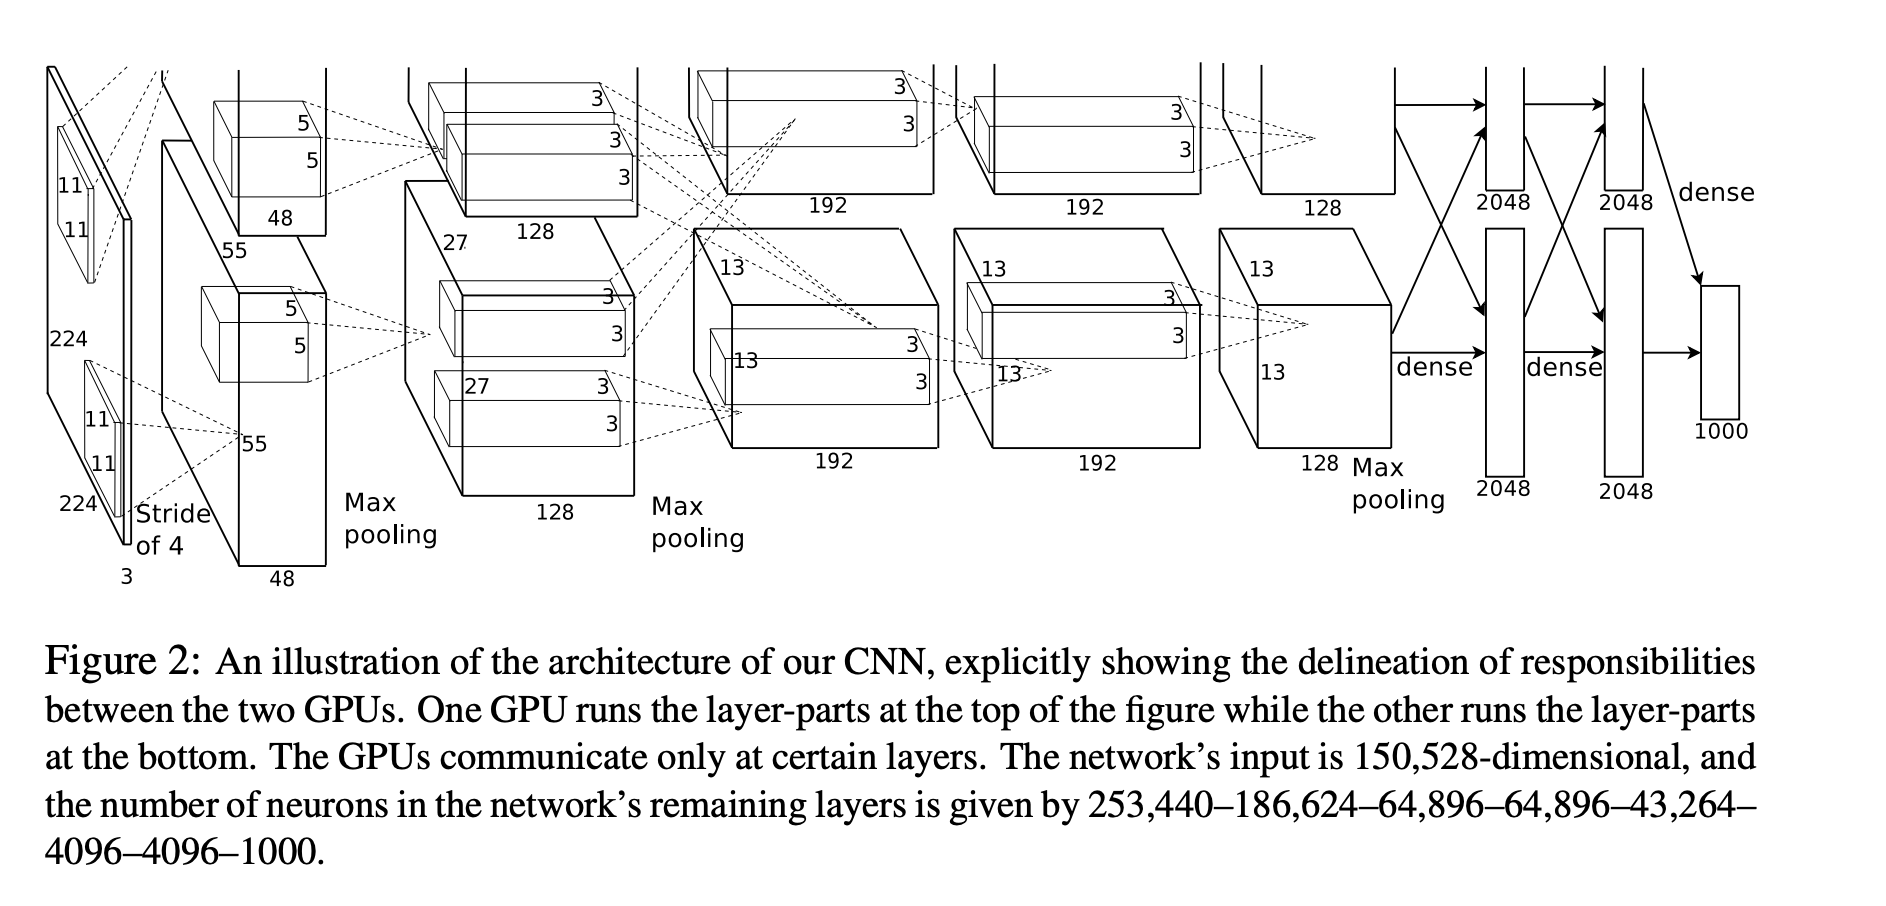

https://docs.pytorch.org/docs/2.13/generated/torch.nn.LocalResponseNorm.html

### Notes on initialsing weights:


In [ ]:
# implement init weights
from torch.nn import Sequential, Conv2d, ReLU, LocalResponseNorm, Linear, MaxPool2d
from torch.nn.functional import max_pool3d
from torch import nn

class AlexNet(nn.Module):
    """
    Neural network model consisting of layers propsed by AlexNet paper.
    """
    def __init__(self, num_classes=1000):
        """
        Define and allocate layers for this neural net.

        Args:
            num_classes (int): number of classes to predict with this model
        """
        super().__init__()
        # input size should be : (b x 3 x 227 x 227)
        # The image in the original paper states that width and height are 224 pixels, but
        # the dimensions after first convolution layer do not lead to 55 x 55.
        self.net = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=96, kernel_size=11, stride=4),  # (b x 96 x 55 x 55) 0
            nn.ReLU(), 
            nn.LocalResponseNorm(size=5, alpha=0.0001, beta=0.75, k=2),  # section 3.3
            nn.MaxPool2d(kernel_size=3, stride=2),  # (b x 96 x 27 x 27)
            nn.Conv2d(96, 256, 5, padding=2),  # (b x 256 x 27 x 27)
            nn.ReLU(),
            nn.LocalResponseNorm(size=5, alpha=0.0001, beta=0.75, k=2),
            nn.MaxPool2d(kernel_size=3, stride=2),  # (b x 256 x 13 x 13)
            nn.Conv2d(256, 384, 3, padding=1),  # (b x 384 x 13 x 13)  | 8 
            nn.ReLU(),
            nn.Conv2d(384, 384, 3, padding=1),  # (b x 384 x 13 x 13) | 10
            nn.ReLU(),
            nn.Conv2d(384, 256, 3, padding=1),  # (b x 256 x 13 x 13) | 12
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),  # (b x 256 x 6 x 6)
        )
        # classifier is just a name for linear layers
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5, inplace=True),
            nn.Linear(in_features=(256 * 6 * 6), out_features=4096), # 1
            nn.ReLU(),
            nn.Dropout(p=0.5, inplace=True),
            nn.Linear(in_features=4096, out_features=4096), # 4
            nn.ReLU(),
            nn.Linear(in_features=4096, out_features=num_classes), # 6
        )
        self.init_weights()  # initialize bias

    def init_weights(self):
        # set weights and biases for net block
        for layer in self.net:
            if isinstance(layer, nn.Conv2d):                nn.init.normal_(layer.weight, mean=0, std=0.01)
        # original paper = 1 for Conv2d layers 2nd, 4th, and 5th conv layfers
        nn.init.constant_(self.net[4].bias, 1)
        nn.init.constant_(self.net[10].bias, 1)
        nn.init.constant_(self.net[12].bias, 1)

        #set weights and biases for the classifier head
        for layer in self.classifier:
            if isinstance(layer, nn.Linear):
                nn.init.normal_(layer.weight, mean = 0 ,std = 0.01)
            nn.init.constant_(self.classifier[1].bias, 1)
            nn.init.constant_(self.classifier[4].bias, 1)
            nn.init.constant_(self.classifier[6].bias, -7)

    def forward(self, x):
        i = 0
        for layer in self.net:    
            x = layer(x)
            # print(f"Layer {i} | {str(layer)} | img.shape = {x.shape}")
            i+=1

        i=0
        flatten = nn.Flatten()
        x = flatten(x)
        for layer in self.classifier:
            x = layer(x)
            # print(f"Layer {i} | {str(layer)} | img.shape = {x.shape}")
            i+=1
        return(x)
       
model = AlexNet()

## (3) Training the network



In [ ]:
from torch.nn import CrossEntropyLoss
from torch.optim import Adam
import wandb
from dotenv import load_dotenv
import os
from tqdm import tqdm
import torch.nn.functional as F

# api-keys
load_dotenv() 
WANDB_API_KEY = os.getenv("WANDB_API_KEY")

#set hyperparams
NUM_EPOCHS = 90
BATCH_SIZE =128
MOMENTUM = 0.9 
WEIGHT_DECAY  = 5e4
LR= 1e4
OUTPUT_PATH = "model.txt" 

#set optimiser, loss and dataloader
train_dl = DataLoader(ds, batch_size=BATCH_SIZE, num_workers=0)
loss_fn = CrossEntropyLoss()
optimizer = Adam(model.parameters(),LR)

#wandb init
TEAM_ENTITY = "elliot-kaute" 
PROJECT = "alexnet-replication"

with wandb.init(project="alexnet-replication", config={"lr": LR, "batch_size": BATCH_SIZE}) as run:
    DEVICE = "cuda" if torch.cuda.is_available() else "mps"
    model.to(DEVICE)
    for epoch in range(NUM_EPOCHS):
        step = 0 
        try:
            for batch in tqdm(iter(train_dl)):
                img = batch['image']
                label = batch['label']
                # print(img.shape, label.shape)
                img = img.to(DEVICE)
                label = label.to(DEVICE)

                # perform grad descent
                with torch.no_grad():
                    optimizer.zero_grad()
                    out = model.forward(img)
                    # tensor of 1000 outputs 
                
                    loss = F.cross_entropy(out, label)
                    loss = loss_fn(out, label)

                    ## !! Important | if requires_grad not set on loss then loss.backward won't run
                    loss.requires_grad = True
                    loss.backward()

                    optimizer.step()
                
                if (step % 5 == 0 ):
                    run.log({
                        "epoch" : epoch,
                        "loss" : loss,
                    })
                step+=1
        except KeyboardInterrupt:
             print("Interrupted — letting wandb close cleanly...")




    

Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x1201c2cf0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 12036ae40, raw_cell="from torch.nn import CrossEntropyLoss
from torch.o.." transformed_cell="from torch.nn import CrossEntropyLoss
from torch.o.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/elliot/Documents/alexnet-replication/alexnet.ipynb#X21sZmlsZQ%3D%3D cell_meta={'cellId': 'vscode-notebook-cell:/Users/elliot/Documents/alexnet-replication/alexnet.ipynb#X21sZmlsZQ%3D%3D'}>,),kwargs {}:


ConnectionResetError: Connection lost

ConnectionResetError: Connection lost

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x1201c2cf0>> (for post_run_cell), with arguments args (<ExecutionResult object at 12036b6b0, execution_count=8 error_before_exec=None error_in_exec=Connection lost info=<ExecutionInfo object at 12036ae40, raw_cell="from torch.nn import CrossEntropyLoss
from torch.o.." transformed_cell="from torch.nn import CrossEntropyLoss
from torch.o.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/elliot/Documents/alexnet-replication/alexnet.ipynb#X21sZmlsZQ%3D%3D cell_meta={'cellId': 'vscode-notebook-cell:/Users/elliot/Documents/alexnet-replication/alexnet.ipynb#X21sZmlsZQ%3D%3D'}> result=None>,),kwargs {}:


ConnectionResetError: Connection lost

Evaluating img access time

In [1]:
print("hello")

hello


In [ ]:
num_exmaples = 1200000
num_exmaples / 128 

Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x11f355590>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 1294978d0, raw_cell="num_exmaples = 1200000
num_exmaples / 128 " transformed_cell="num_exmaples = 1200000
num_exmaples / 128 
" store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/elliot/Documents/alexnet-replication/alexnet.ipynb#X51sZmlsZQ%3D%3D cell_meta={'cellId': 'vscode-notebook-cell:/Users/elliot/Documents/alexnet-replication/alexnet.ipynb#X51sZmlsZQ%3D%3D'}>,),kwargs {}:


ConnectionResetError: Connection lost

9375.0

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x11f355590>> (for post_run_cell), with arguments args (<ExecutionResult object at 124043530, execution_count=10 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 1294978d0, raw_cell="num_exmaples = 1200000
num_exmaples / 128 " transformed_cell="num_exmaples = 1200000
num_exmaples / 128 
" store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/elliot/Documents/alexnet-replication/alexnet.ipynb#X51sZmlsZQ%3D%3D cell_meta={'cellId': 'vscode-notebook-cell:/Users/elliot/Documents/alexnet-replication/alexnet.ipynb#X51sZmlsZQ%3D%3D'}> result=9375.0>,),kwargs {}:


ConnectionResetError: Connection lost

In [ ]:
type(model)

__main__.AlexNet

In [ ]:
tmp1 = model.named_parameters()
for name,param in tmp1:
    print(name)
    print(param.shape)

net.0.weight
torch.Size([96, 3, 11, 11])
net.0.bias
torch.Size([96])
net.4.weight
torch.Size([256, 96, 5, 5])
net.4.bias
torch.Size([256])
net.8.weight
torch.Size([384, 256, 3, 3])
net.8.bias
torch.Size([384])
net.10.weight
torch.Size([384, 384, 3, 3])
net.10.bias
torch.Size([384])
net.12.weight
torch.Size([256, 384, 3, 3])
net.12.bias
torch.Size([256])
classifier.1.weight
torch.Size([4096, 9216])
classifier.1.bias
torch.Size([4096])
classifier.4.weight
torch.Size([4096, 4096])
classifier.4.bias
torch.Size([4096])
classifier.6.weight
torch.Size([1000, 4096])
classifier.6.bias
torch.Size([1000])


In [ ]:

from dotenv import load_dotenv
import os


print(WANDB_API_KEY)  # sanity check — remove after



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


In [ ]:
ds

IterableDataset({
    features: Unknown,
    num_shards: 294
})

In [ ]:
type(optimizer)

torch.optim.adam.Adam

## Notes on Normlaisation layers

What is local response norm?

What is the difference between a batch norm layer and a local response norml ayer?

Why use it?
It aids generalisation although it is not needed to preen nput from saturating.


<img src="lrn.png" width="650">



In [ ]:
# Observing how local_response_norm works
from torch import _VF, sym_int as _sym_int, Tensor
from torch.nn import AvgPool2d,  AvgPool3d
from torch.nn.functional import pad, avg_pool3d, avg_pool2d
from torch.nn.functional import max_pool3d


def local_response_norm(input, size=5, alpha=1e-4, beta=0.75, k=2):
    r"""Applies local response normalization over an input signal composed of
    several input planes, where channels occupy the second dimension.
    Applies normalization across channels.
    See :class:`~torch.nn.LocalResponseNorm` for details.
    """
    dim = input.dim()
    if dim < 3:
        raise ValueError('Expected 3D or higher dimensionality \
                         input (got {} dimensions)'.format(dim))
    div = input.mul(input).unsqueeze(1)
    if dim == 3:
        div = pad(div, (0, 0, size // 2, (size - 1) // 2))
        div = F.avg_pool2d(div, (size, 1), stride=1).squeeze(1)
    else:
        sizes = input.size()
        div = div.view(sizes[0], 1, sizes[1], sizes[2], -1)
        div = pad(div, (0, 0, 0, 0, size // 2, (size - 1) // 2))
        div = F.max_pool3d(div, (size, 1, 1), stride=1).squeeze(1)
        div = div.view(sizes)
    div = div.mul(alpha).add(k).pow(beta)
    return input / div

x = torch.randn(32, 3, 256, 256)
tmp1 = local_response_norm(x)

tmp1.shape



NameError: name 'F' is not defined

In [ ]:
from torch.nn import Module

class LocalResponseNorm(Module):
    __constants__ = ["size", "alpha", "beta", "k"]
    size: int
    alpha: float
    beta: float
    k: float

    def __init__(
        self, size: int, alpha: float = 1e-4, beta: float = 0.75, k: float = 1.0
    ) -> None:
        super().__init__()
        self.size = size
        self.alpha = alpha
        self.beta = beta
        self.k = k

    def forward(self, input: Tensor) -> Tensor:
        """
        Runs the forward pass.
        """
        return F.local_response_norm(input, self.size, self.alpha, self.beta, self.k)

    def extra_repr(self):
        """
        Return the extra representation of the module.
        """
        return "{size}, alpha={alpha}, beta={beta}, k={k}".format(**self.__dict__)


In [ ]:
print(arr1)
arr2

[2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5, 10.5, 11, 11, 11]


[0, 0, 0, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5]

## Section 1 Notes


### On the importance of downsampling 

**Why Do we downsample?**
- Reduce storage size of data
- Reduce dimensionality, enable faster processign

# XML Shenanigans

## Notes

---
<h1>XML</h1>
What is XML?
Link: https://www.w3schools.com/xml/xml_whatis.asp


General definition: Tool for storing and transportind data. It is a markup language.

What is the difference between XML and HTML?
- XML designed to carray data whereas html designed to explain data.
- XML tags are also not predefined e.g <to><from> are invented by the author of the xml document whereas , <p> etc. are predefined in html
- XML is extensible, xml applications still work when data is removed or added
- XML simplifies data sharing, data transport etc. Very useful because not much extra effort has to be spent on ensurign the data is compatible across different systems

---

<h1>Pascal VOC XML</h1>

**What is Pascal VOC XML format?**
Link : https://roboflow.com/formats/pascal-voc-xml

Originally created for the Pascal visual object challenge (a highly influential annual benhcmark comp in cv)
It is a common interchange format for object detection labels. Can be exported from many label tools : CVAT etc.
Is a common XML annotation format.

**What is an example of an XML file in this format:**

img0001.xml
```xml
<annotation>
	<folder></folder>
	<filename>000001.jpg</filename>
	<path>000001.jpg</path>
	<source>
		<database>roboflow.ai</database>
	</source>
	<size>
		<width>500</width>
		<height>375</height>
		<depth>3</depth>
	</size>
	<segmented>0</segmented>
	<object>
		<name>helmet</name>
		<pose>Unspecified</pose>
		<truncated>0</truncated>
		<difficult>0</difficult>
		<occluded>0</occluded>
		<bndbox>
			<xmin>179</xmin>
			<xmax>231</xmax>
			<ymin>85</ymin>
			<ymax>144</ymax>
		</bndbox>
	</object>
	<object>
		<name>helmet</name>
		<pose>Unspecified</pose>
		<truncated>0</truncated>
		<difficult>0</difficult>
		<occluded>0</occluded>
		<bndbox>
			<xmin>112</xmin>
			<xmax>135</xmax>
			<ymin>145</ymin>
			<ymax>175</ymax>
		</bndbox>
	</object>
</annotation>
```


## 1 How to read an xml 

- Link : https://www.geeksforgeeks.org/python/reading-and-writing-xml-files-in-python/

In [ ]:
# How to read an xml file, use bs4
from bs4 import BeautifulSoup

with open('dict.xml', 'r') as f:
    data = f.read()

Bs_data = BeautifulSoup(data, "xml")

b_unique = Bs_data.find_all('unique')

b_unique





[<unique>
  Add a video URL in here
  </unique>,
 <unique>
  Add a workbook URL here
  </unique>]

## 2 How to read an xml file from the Kaggle ImageNet subset
- Link : https://www.kaggle.com/competitions/imagenet-object-localization-challenge/code

- How to parse img annotations
**What is a compiler**
Converts high level programming language to binary

**What is pascal**
Old ass programming language

**What is the pascal development toolkit**
Free Pascal is a open source Pascal compiller





## 3 What is an iter in python?

Iterable is antrhing that can be looped over. An iterator is the object that walks through it

What is a stream of data?
Sequence of items that arrives one at a time over time

What does inbuilt func iter() do?
Returns an iterator object

What is an iterator?
https://docs.python.org/3/glossary.html#term-iterator

Object representing stream of data. 


## 4 With statements

**What is a statement in python?**
https://docs.python.org/3/reference/simple_stmts.html#grammar-token-python-grammar-expression_stmt
https://docs.python.org/3/reference/compound_stmts.html#the-with-statement

In python program instructions are statements i.e each line is a statement

There are two types of statements in python:
- Simple : A single instruction
- Compound : Contains multiple statemtns within it and effects their execution

**What is a context manager**
https://docs.python.org/3/reference/datamodel.html#context-managers
Defines the runtiem context to be established

Typical usages:
- save and restore global state
- locking and unlocking resoruces
- closign opened fiels

**What is a resource?**
Resources include throughput, cache and memory. Limited components accessible to a computer

**What is a with statement?**
Si

**What is a factory function**
A function that create different types of objects based on runtime conditions.

**What is an interface**
Abstract class that specifies a set of methods or properties. Specifies what to do but not how to do it

Interfaces dont exist in python so we use Abstract base classes

It forces the implenetation of a method e.g the area() method of all subclasses inherting the abstract base class

**What exactly is a context manager**
https://www.youtube.com/watch?v=-aKFBoZpiqA

**What is cypthon**
The Reference implemtation of python. I.e the default way we run python programs. 
Pass in python source code into it, and cypton interperets it according to the python spec
Then compiles it

**What is the io module**
Is a part of the python standard library. It is a built in module written in c

three main types of io:
-text 
- binary
-raw

**open()**
open() function opens a file, and returns it as a file object

An object belonging to any of these projects is a file object/ stream / file-like object

**what is the difference between text editor and cmd line text editor**
text editor- brings open new tab, enables you to edit text
cmd line text editor - allows you to edit text straigth from the terminal